In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from torch_geometric.nn import SAGEConv

In [2]:
K_NEIGHBORS = 8

HIDDEN = 64
EPOCHS = 200
LR = 0.01
WEIGHT_DECAY = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
X_df = pd.read_parquet(
    "../data/processed_predictors/atlanta_2023_predictor_dataset.parquet"
)

y_df = pd.read_parquet(
    "../data/processed_job_accessibility/accessibility_state-GA_counties-121-089-067-135_year-2023_thresholds-15-30-45-60.parquet"
)

In [4]:
y_df = y_df.sort_values("from_id").reset_index(drop=True)

weights = np.array([1.0, 0.7, 0.4, 0.2])

band_0_15 = y_df["jobs_15min"].clip(lower=0)
band_15_30 = (y_df["jobs_30min"] - y_df["jobs_15min"]).clip(lower=0)
band_30_45 = (y_df["jobs_45min"] - y_df["jobs_30min"]).clip(lower=0)
band_45_60 = (y_df["jobs_60min"] - y_df["jobs_45min"]).clip(lower=0)

weighted_sum = (
    weights[0] * band_0_15 +
    weights[1] * band_15_30 +
    weights[2] * band_30_45 +
    weights[3] * band_45_60
)

y_df["target"] = np.log1p(weighted_sum)

In [5]:
df = X_df.merge(
    y_df[["from_id", "target"]],
    left_on="tract_id",
    right_on="from_id",
    how="inner"
)

In [6]:
STATE = "13"
COUNTIES = ["121", "089", "067", "135"]

url = (
    f"https://www2.census.gov/geo/tiger/TIGER2023/"
    f"TRACT/tl_2023_{STATE}_tract.zip"
)

tracts = gpd.read_file(url)
tracts = tracts[tracts["COUNTYFP"].isin(COUNTIES)].copy()
tracts["tract_id"] = tracts["GEOID"].astype(str)

df = df.merge(
    tracts[["tract_id", "geometry"]],
    on="tract_id",
    how="left"
)

gdf = gpd.GeoDataFrame(df, geometry="geometry", crs=tracts.crs)
gdf = gdf.to_crs(epsg=5070)

In [7]:
gdf["centroid"] = gdf.geometry.centroid
gdf["x"] = gdf.centroid.x
gdf["y"] = gdf.centroid.y

coords = np.column_stack([gdf["x"], gdf["y"]])

drop_cols = ["tract_id", "from_id", "geometry", "centroid", "target"]

feature_cols = [c for c in gdf.columns if c not in drop_cols]

X_np = gdf[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0).values

scaler = StandardScaler()
X_np = scaler.fit_transform(X_np)

X = torch.tensor(X_np, dtype=torch.float)
y = torch.tensor(gdf["target"].values, dtype=torch.float)

In [8]:
def build_knn_graph(coords, k=K_NEIGHBORS):
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(coords)

    _, idx = nn.kneighbors(coords)

    edges = []
    for i in range(len(coords)):
        for j in idx[i]:
            if i != j:
                edges.append((i, j))

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    return edge_index


edge_index = build_knn_graph(coords)

In [9]:
train_idx, test_idx = train_test_split(
    np.arange(len(gdf)),
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.2,
    random_state=42
)

train_mask = torch.zeros(len(gdf), dtype=torch.bool)
val_mask = torch.zeros(len(gdf), dtype=torch.bool)
test_mask = torch.zeros(len(gdf), dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

In [10]:
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden=64):
        super().__init__()

        self.conv1 = SAGEConv(in_channels, hidden)
        self.conv2 = SAGEConv(hidden, hidden)

        self.lin = torch.nn.Linear(hidden, 1)

    def forward(self, x, edge_index):
        x1 = F.relu(self.conv1(x, edge_index))
        x2 = F.relu(self.conv2(x1, edge_index))

        x = x1 + x2
        return self.lin(x).squeeze()

In [11]:
model = GraphSAGE(in_channels=X.shape[1], hidden=HIDDEN).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

loss_fn = torch.nn.MSELoss()

X = X.to(device)
y = y.to(device)
edge_index = edge_index.to(device)

train_mask = train_mask.to(device)
val_mask = val_mask.to(device)
test_mask = test_mask.to(device)

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    model.train()
    optimizer.zero_grad()

    out = model(X, edge_index)

    loss = loss_fn(out[train_mask], y[train_mask])

    loss.backward()
    optimizer.step()

    # validation
    model.eval()
    with torch.no_grad():
        val_out = model(X, edge_index)
        val_loss = loss_fn(val_out[val_mask], y[val_mask])

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Train {loss:.4f} | Val {val_loss:.4f}")

Epoch 0 | Train 109.0445 | Val 77.2292
Epoch 20 | Train 2.1481 | Val 2.0871
Epoch 40 | Train 0.7721 | Val 1.0537
Epoch 60 | Train 0.4615 | Val 0.8367
Epoch 80 | Train 0.3112 | Val 0.6549
Epoch 100 | Train 0.2307 | Val 0.5926
Epoch 120 | Train 0.1798 | Val 0.5483
Epoch 140 | Train 0.1453 | Val 0.5194
Epoch 160 | Train 0.1207 | Val 0.5042
Epoch 180 | Train 0.1020 | Val 0.4982


In [12]:
model.eval()

with torch.no_grad():
    pred = model(X, edge_index).cpu().numpy()

y_true = y[test_mask].cpu().numpy()
y_pred = pred[test_mask.cpu().numpy()]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("TEST RESULTS")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

TEST RESULTS
MAE: 0.5315655469894409
RMSE: 0.6717976148530072
R2: 0.7883145809173584


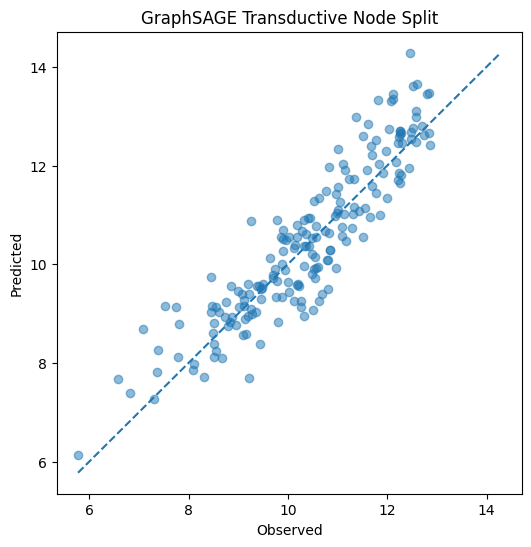

In [13]:
plt.figure(figsize=(6,6))

plt.scatter(y_true, y_pred, alpha=0.5)

mn = min(y_true.min(), y_pred.min())
mx = max(y_true.max(), y_pred.max())

plt.plot([mn, mx], [mn, mx], "--")

plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("GraphSAGE Transductive Node Split")

plt.show()